In [1]:
# Cell 2: Import all libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Plot styling
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette("Set2")

In [4]:
from google.colab import files
files.upload()


Saving Sample - Superstore.csv to Sample - Superstore (2).csv


{'Sample - Superstore (2).csv': b'Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit\r\n1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0,41.9136\r\n2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs, Rounded Back",731.94,3,0,219.582\r\n3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters by Universal,14.62,2,0,6.8714\r\n4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO

In [8]:
# Cell 4: Data Overview
df = pd.read_csv('Sample - Superstore (2).csv', encoding='latin1')

# Convert 'Order Date' to datetime objects
df['Order Date'] = pd.to_datetime(df['Order Date'])

print("=" * 55)
print("           DATASET OVERVIEW")
print("=" * 55)
print(f"\n Shape       : {df.shape}")
print(f"Date Range  : {df['Order Date'].min().date()} → {df['Order Date'].max().date()}")
print(f"Orders      : {df['Order ID'].nunique():,}")
print(f"Customers   : {df['Customer ID'].nunique():,}")
print(f"Cities      : {df['City'].nunique():,}")
print(f"Categories  : {df['Category'].unique()}")

print("\n--- Missing Values ---")
print(df.isnull().sum()[df.isnull().sum() > 0])

print("\n--- Data Types ---")
print(df.dtypes)

           DATASET OVERVIEW

 Shape       : (9994, 21)
Date Range  : 2014-01-03 → 2017-12-30
Orders      : 5,009
Customers   : 793
Cities      : 531
Categories  : ['Furniture' 'Office Supplies' 'Technology']

--- Missing Values ---
Series([], dtype: int64)

--- Data Types ---
Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date                object
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code               int64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
dtype: object


In [9]:
# Cell 5: Feature Engineering
df['Year']         = df['Order Date'].dt.year
df['Month']        = df['Order Date'].dt.month
df['Month Name']   = df['Order Date'].dt.strftime('%b')
df['Quarter']      = df['Order Date'].dt.quarter
df['YearMonth']    = df['Order Date'].dt.to_period('M')
df['YearMonthStr'] = df['Order Date'].dt.strftime('%Y-%m')

# Derived metrics
df['Profit Margin %'] = (df['Profit'] / df['Sales']) * 100

print("New columns added:", ['Year','Month','Month Name','Quarter',
                                 'YearMonth','YearMonthStr','Profit Margin %'])
df[['Sales','Profit','Profit Margin %']].describe().round(2)

New columns added: ['Year', 'Month', 'Month Name', 'Quarter', 'YearMonth', 'YearMonthStr', 'Profit Margin %']


,Sales,Profit,Profit Margin %
count,9994.00,9994.00,9994.00
mean,229.86,28.66,12.03
std,623.25,234.26,46.68
min,0.44,-6599.98,-275.00
25%,17.28,1.73,7.50
50%,54.49,8.67,27.00
75%,209.94,29.36,36.25
max,22638.48,8399.98,50.00


In [10]:
# Cell 6: High-level KPIs
total_sales    = df['Sales'].sum()
total_profit   = df['Profit'].sum()
total_orders   = df['Order ID'].nunique()
avg_margin     = (total_profit / total_sales) * 100
total_quantity = df['Quantity'].sum()

print("=" * 55)
print("          KEY PERFORMANCE INDICATORS")
print("=" * 55)
print(f"Total Revenue    : ${total_sales:>12,.2f}")
print(f"Total Profit     : ${total_profit:>12,.2f}")
print(f"Total Orders     : {total_orders:>12,}")
print(f"Units Sold       : {total_quantity:>12,}")
print(f"Profit Margin    : {avg_margin:>11.2f}%")
print(f"Avg Order Value  : ${total_sales/total_orders:>12,.2f}")
print("=" * 55)

          KEY PERFORMANCE INDICATORS
Total Revenue    : $2,297,200.86
Total Profit     : $  286,397.02
Total Orders     :        5,009
Units Sold       :       37,873
Profit Margin    :       12.47%
Avg Order Value  : $      458.61


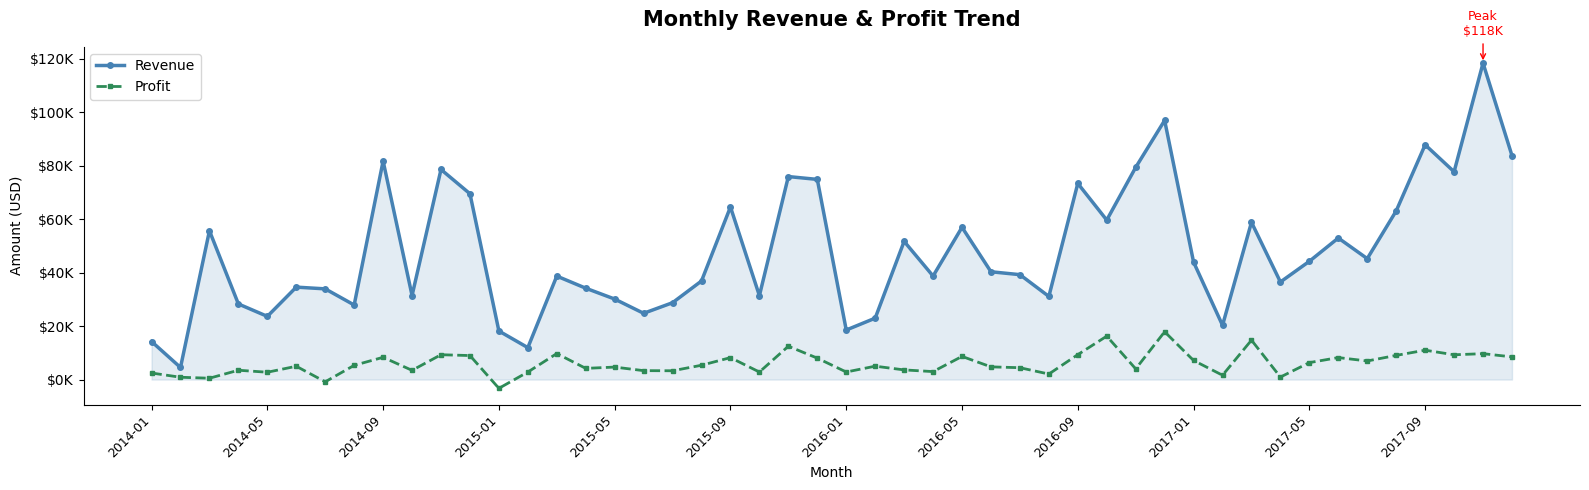


Best Month  : 2017-11 — $118,448
Worst Month : 2014-02 — $4,520


In [11]:
# Cell 7: Monthly Revenue Trend
monthly = (df.groupby('YearMonthStr')[['Sales','Profit']]
             .sum()
             .reset_index()
             .sort_values('YearMonthStr'))

fig, ax = plt.subplots(figsize=(16, 5))
ax.fill_between(monthly['YearMonthStr'], monthly['Sales'], alpha=0.15, color='steelblue')
ax.plot(monthly['YearMonthStr'], monthly['Sales'], color='steelblue',
        linewidth=2.5, marker='o', markersize=4, label='Revenue')
ax.plot(monthly['YearMonthStr'], monthly['Profit'], color='seagreen',
        linewidth=2, linestyle='--', marker='s', markersize=3, label='Profit')

# Highlight max month
max_idx = monthly['Sales'].idxmax()
ax.annotate(f"Peak\n${monthly.loc[max_idx,'Sales']/1000:.0f}K",
            xy=(monthly.loc[max_idx,'YearMonthStr'], monthly.loc[max_idx,'Sales']),
            xytext=(0, 20), textcoords='offset points',
            arrowprops=dict(arrowstyle='->', color='red'),
            fontsize=9, color='red', ha='center')

tick_step = max(1, len(monthly) // 12)
ax.set_xticks(monthly['YearMonthStr'][::tick_step])
ax.set_xticklabels(monthly['YearMonthStr'][::tick_step], rotation=45, ha='right', fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.set_title('Monthly Revenue & Profit Trend', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Month'); ax.set_ylabel('Amount (USD)')
ax.legend(); plt.tight_layout(); plt.show()

print(f"\nBest Month  : {monthly.loc[max_idx,'YearMonthStr']} — ${monthly.loc[max_idx,'Sales']:,.0f}")
print(f"Worst Month : {monthly.loc[monthly['Sales'].idxmin(),'YearMonthStr']} — ${monthly['Sales'].min():,.0f}")

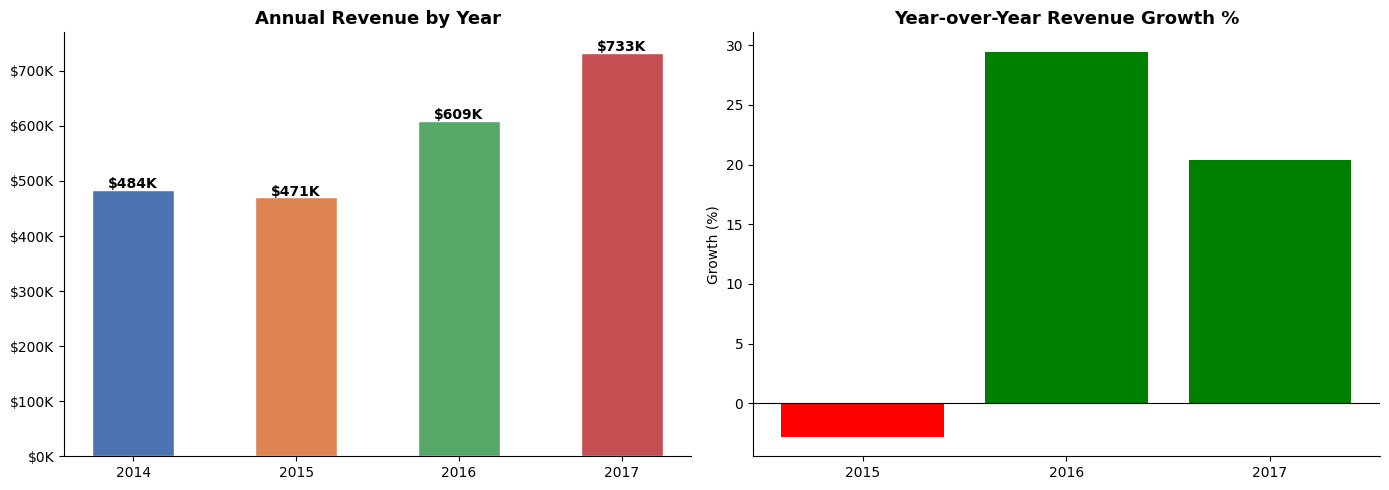

 Year       Sales     Profit  Quantity  Growth %
 2014 484247.4981 49543.9741      7581       NaN
 2015 470532.5090 61618.6037      7979 -2.832227
 2016 609205.5980 81795.1743      9837 29.471521
 2017 733215.2552 93439.2696     12476 20.355962


In [12]:
# Cell 8: Year-over-Year Comparison
yearly = df.groupby('Year')[['Sales','Profit','Quantity']].sum().reset_index()
yearly['Growth %'] = yearly['Sales'].pct_change() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
axes[0].bar(yearly['Year'].astype(str), yearly['Sales'], color=['#4C72B0','#DD8452','#55A868','#C44E52'],
            edgecolor='white', width=0.5)
for i, row in yearly.iterrows():
    axes[0].text(i, row['Sales'] + 3000, f"${row['Sales']/1000:.0f}K",
                 ha='center', fontweight='bold', fontsize=10)
axes[0].set_title('Annual Revenue by Year', fontweight='bold', fontsize=13)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

# Growth rate
axes[1].bar(yearly['Year'].astype(str)[1:], yearly['Growth %'].dropna(),
            color=['green' if x > 0 else 'red' for x in yearly['Growth %'].dropna()])
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Year-over-Year Revenue Growth %', fontweight='bold', fontsize=13)
axes[1].set_ylabel('Growth (%)')

plt.tight_layout(); plt.show()
print(yearly.to_string(index=False))

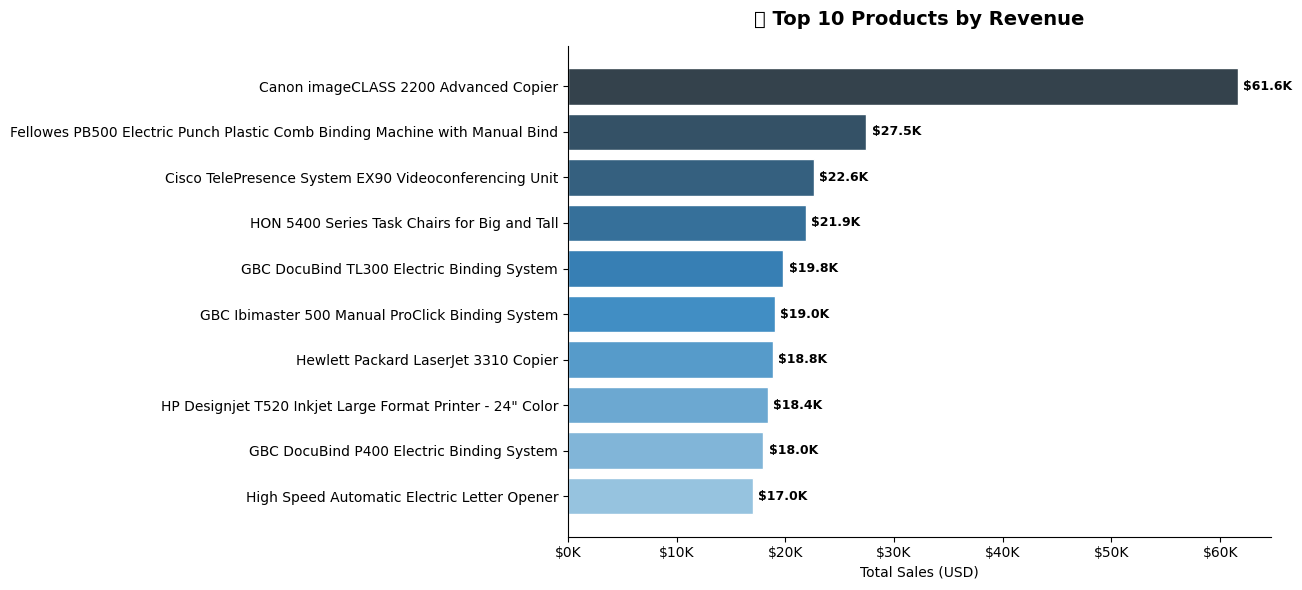


Top 10 Products:
                                                               Product Name     Sales
                                      Canon imageCLASS 2200 Advanced Copier 61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind 27453.384
                      Cisco TelePresence System EX90 Videoconferencing Unit 22638.480
                               HON 5400 Series Task Chairs for Big and Tall 21870.576
                                 GBC DocuBind TL300 Electric Binding System 19823.479
                           GBC Ibimaster 500 Manual ProClick Binding System 19024.500
                                       Hewlett Packard LaserJet 3310 Copier 18839.686
                  HP Designjet T520 Inkjet Large Format Printer - 24" Color 18374.895
                                  GBC DocuBind P400 Electric Binding System 17965.068
                                High Speed Automatic Electric Letter Opener 17030.312


In [13]:
# Cell 9: Top 10 Products by Revenue
top_products = (df.groupby('Product Name')['Sales']
                  .sum()
                  .sort_values(ascending=False)
                  .head(10)
                  .reset_index())

fig, ax = plt.subplots(figsize=(13, 6))
bars = ax.barh(top_products['Product Name'][::-1], top_products['Sales'][::-1],
               color=sns.color_palette("Blues_d", 10), edgecolor='white')
for bar, val in zip(bars, top_products['Sales'][::-1]):
    ax.text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
            f'${val/1000:.1f}K', va='center', fontsize=9, fontweight='bold')

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.set_title('🏆 Top 10 Products by Revenue', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Total Sales (USD)')
plt.tight_layout(); plt.show()

print("\nTop 10 Products:")
print(top_products.to_string(index=False))

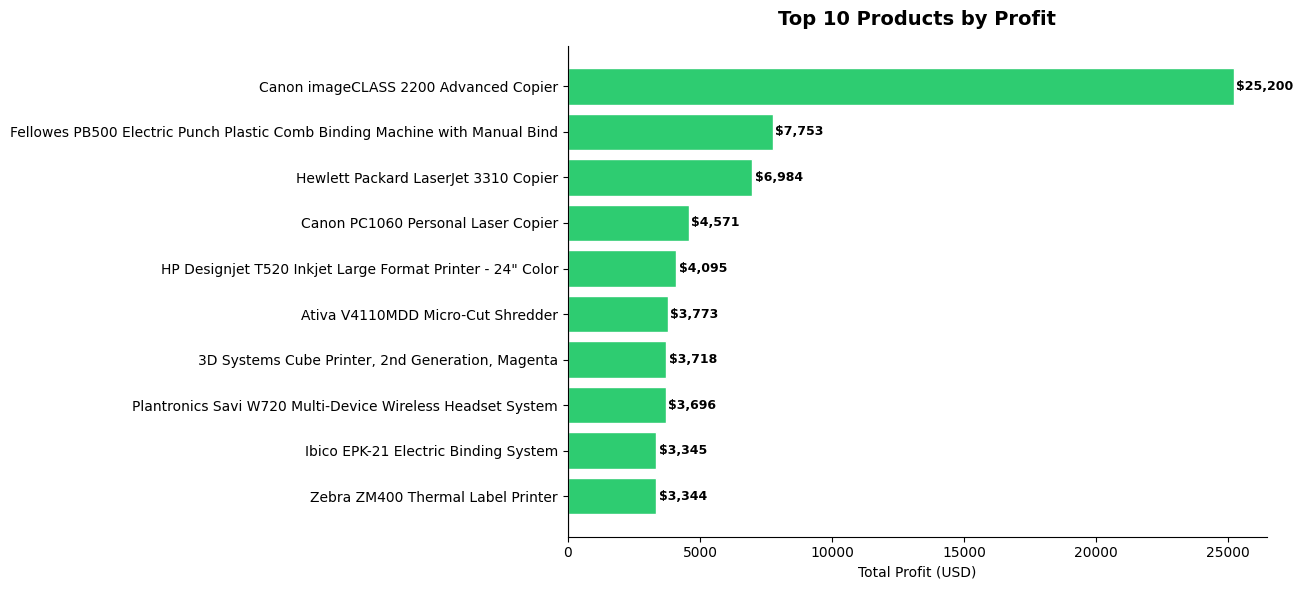

In [14]:
# Cell 10: Top 10 Products by Profit
top_profit_products = (df.groupby('Product Name')['Profit']
                         .sum()
                         .sort_values(ascending=False)
                         .head(10)
                         .reset_index())

fig, ax = plt.subplots(figsize=(13, 6))
colors = ['#2ecc71' if p > 0 else '#e74c3c' for p in top_profit_products['Profit'][::-1]]
bars = ax.barh(top_profit_products['Product Name'][::-1],
               top_profit_products['Profit'][::-1], color=colors, edgecolor='white')
for bar, val in zip(bars, top_profit_products['Profit'][::-1]):
    ax.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
            f'${val:,.0f}', va='center', fontsize=9, fontweight='bold')

ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Top 10 Products by Profit', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Total Profit (USD)')
plt.tight_layout(); plt.show()

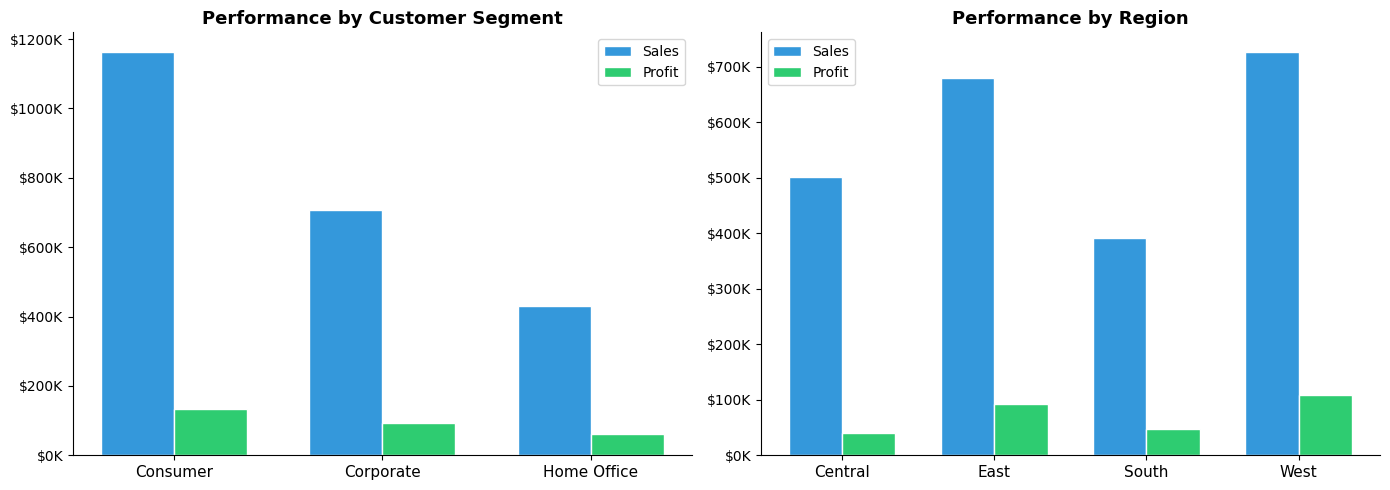

In [15]:
# Cell 12: Segment & Region Profit Analysis
seg   = df.groupby('Segment')[['Sales','Profit']].sum().reset_index()
region = df.groupby('Region')[['Sales','Profit']].sum().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, data, col, title in [
    (axes[0], seg,    'Segment', 'Performance by Customer Segment'),
    (axes[1], region, 'Region',  'Performance by Region')
]:
    x = np.arange(len(data))
    w = 0.35
    ax.bar(x - w/2, data['Sales'],  width=w, label='Sales',  color='#3498db', edgecolor='white')
    ax.bar(x + w/2, data['Profit'], width=w, label='Profit', color='#2ecc71', edgecolor='white')
    ax.set_xticks(x); ax.set_xticklabels(data[col], fontsize=11)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
    ax.set_title(title, fontweight='bold', fontsize=13)
    ax.legend()

plt.tight_layout(); plt.show()

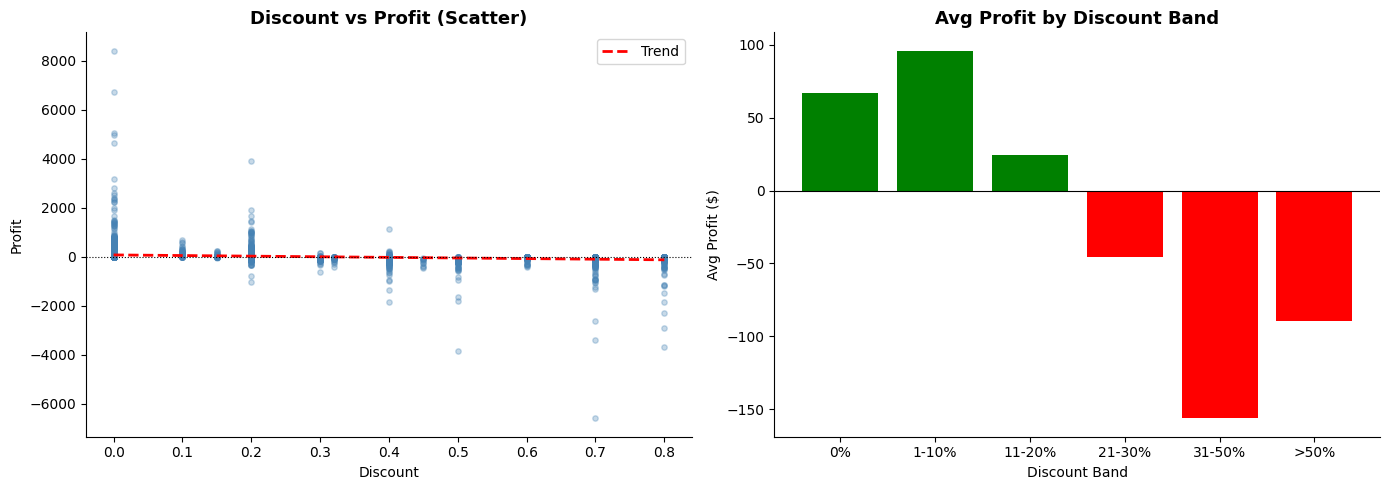

Correlation (Discount ↔ Profit): -0.2195


In [17]:
# Cell 13: Discount Impact on Profit
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter
axes[0].scatter(df['Discount'], df['Profit'], alpha=0.3, c='steelblue', s=15)
z = np.polyfit(df['Discount'], df['Profit'], 1)
p = np.poly1d(z)
x_line = np.linspace(0, df['Discount'].max(), 100)
axes[0].plot(x_line, p(x_line), 'r--', linewidth=2, label='Trend')
axes[0].axhline(0, color='black', linewidth=0.8, linestyle=':')
axes[0].set_xlabel('Discount'); axes[0].set_ylabel('Profit')
axes[0].set_title('Discount vs Profit (Scatter)', fontweight='bold', fontsize=13)
axes[0].legend()

# Avg profit per discount band
df['Discount Band'] = pd.cut(df['Discount'],
                              bins=[-0.01, 0, 0.1, 0.2, 0.3, 0.5, 1.0],
                              labels=['0%','1-10%','11-20%','21-30%','31-50%','>50%'])
disc_profit = df.groupby('Discount Band')['Profit'].mean().reset_index()
colors = ['green' if p > 0 else 'red' for p in disc_profit['Profit']]
axes[1].bar(disc_profit['Discount Band'].astype(str), disc_profit['Profit'], color=colors)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Avg Profit by Discount Band', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Discount Band'); axes[1].set_ylabel('Avg Profit ($)')

plt.tight_layout(); plt.show()

corr = df['Discount'].corr(df['Profit'])
print(f"Correlation (Discount ↔ Profit): {corr:.4f}")

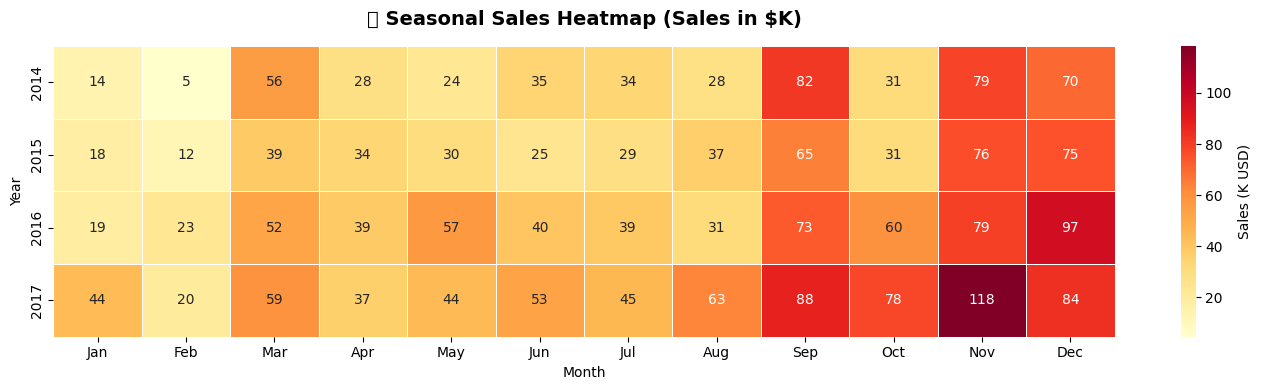

In [18]:
# Cell 14: Monthly-Yearly Heatmap (Seasonality)
pivot = df.pivot_table(values='Sales', index='Year', columns='Month', aggfunc='sum')
pivot.columns = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

plt.figure(figsize=(14, 4))
sns.heatmap(pivot / 1000, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': 'Sales (K USD)'})
plt.title('🗓️ Seasonal Sales Heatmap (Sales in $K)', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Year'); plt.xlabel('Month')
plt.tight_layout(); plt.show()

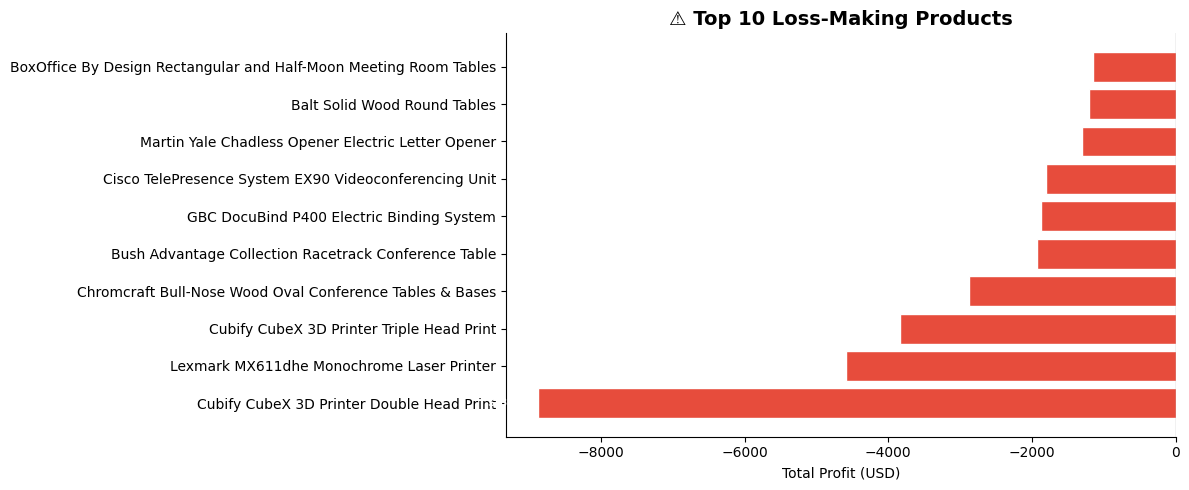

In [19]:
# Cell 15: Most Loss-Making Products
loss = (df.groupby('Product Name')['Profit']
          .sum()
          .sort_values()
          .head(10)
          .reset_index())

fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(loss['Product Name'], loss['Profit'], color='#e74c3c', edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('⚠️ Top 10 Loss-Making Products', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Profit (USD)')
for i, row in loss.iterrows():
    ax.text(row['Profit'] - 50, i, f'${row["Profit"]:,.0f}', va='center',
            ha='right', fontsize=8, color='white', fontweight='bold')
plt.tight_layout(); plt.show()

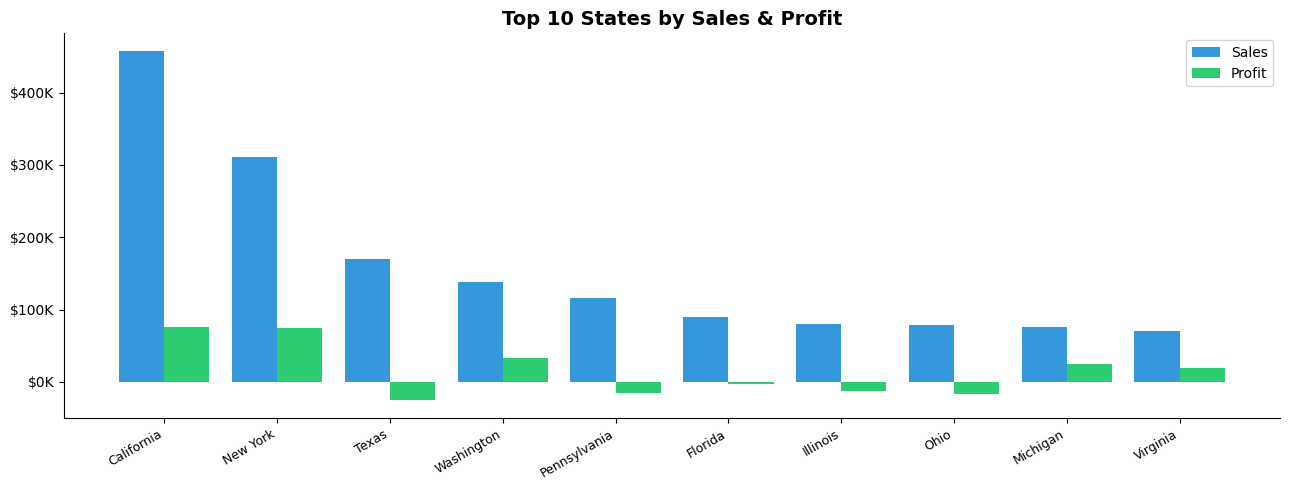

In [21]:
# Cell 16: Geographic Analysis – Top States
state = (df.groupby('State')[['Sales','Profit']]
           .sum()
           .sort_values('Sales', ascending=False)
           .head(10)
           .reset_index())

fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(len(state))
ax.bar(x - 0.2, state['Sales'],  0.4, label='Sales',  color='#3498db')
ax.bar(x + 0.2, state['Profit'], 0.4, label='Profit', color='#2ecc71')
ax.set_xticks(x); ax.set_xticklabels(state['State'], rotation=30, ha='right', fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.set_title('Top 10 States by Sales & Profit', fontsize=14, fontweight='bold')
ax.legend(); plt.tight_layout(); plt.show()

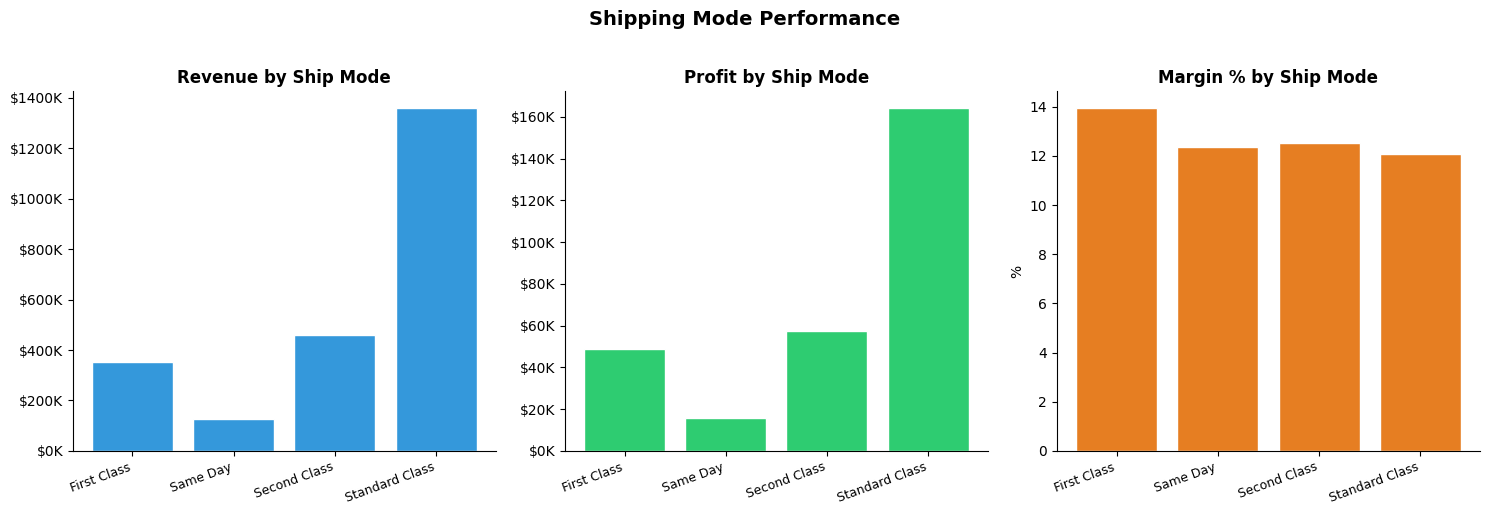

     Ship Mode        Sales      Profit  Quantity  Margin %
   First Class  351428.4229  48969.8399      5693 13.934513
      Same Day  128363.1250  15891.7589      1960 12.380315
  Second Class  459193.5694  57446.6354      7423 12.510331
Standard Class 1358215.7430 164088.7875     22797 12.081202


In [22]:
# Cell 17: Ship Mode Analysis
ship = df.groupby('Ship Mode')[['Sales','Profit','Quantity']].sum().reset_index()
ship['Margin %'] = (ship['Profit'] / ship['Sales']) * 100

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics = [('Sales','Revenue','#3498db'), ('Profit','Profit','#2ecc71'), ('Margin %','Margin %','#e67e22')]
for ax, (col, title, color) in zip(axes, metrics):
    ax.bar(ship['Ship Mode'], ship[col], color=color, edgecolor='white')
    ax.set_xticklabels(ship['Ship Mode'], rotation=20, ha='right', fontsize=9)
    ax.set_title(f'{title} by Ship Mode', fontweight='bold')
    if col != 'Margin %':
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
    else:
        ax.set_ylabel('%')

plt.suptitle('Shipping Mode Performance', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()
print(ship.to_string(index=False))

In [23]:
# Cell 18: Print Final Business Insights Report
sep = "=" * 60

# Gather key stats
best_cat    = df.groupby('Category')['Sales'].sum().idxmax()
best_seg    = df.groupby('Segment')['Sales'].sum().idxmax()
best_region = df.groupby('Region')['Profit'].sum().idxmax()
worst_subcat= df.groupby('Sub-Category')['Profit'].sum().idxmin()
best_ship   = df.groupby('Ship Mode')['Profit'].sum().idxmax()
best_month  = df.groupby('Month Name')['Sales'].sum().idxmax()

print(sep)
print("       SUPERSTORE BUSINESS INSIGHTS REPORT")
print(sep)
print(f"""
1. REVENUE SUMMARY
   ├─ Total Revenue     : ${df['Sales'].sum():>12,.2f}
   ├─ Total Profit      : ${df['Profit'].sum():>12,.2f}
   ├─ Profit Margin     : {(df['Profit'].sum()/df['Sales'].sum())*100:>11.2f}%
   └─ Total Orders      : {df['Order ID'].nunique():>12,}

2. MONTHLY TRENDS
   ├─ Peak Sales Month  : {best_month}
   ├─ Q4 dominates YoY with consistent revenue spikes
   └─ Year-over-Year growth observed each year

3. TOP PERFORMING PRODUCTS
   ├─ Best Category     : {best_cat}
   ├─ Best Sub-Cat      : {df.groupby('Sub-Category')['Sales'].sum().idxmax()}
   └─ Worst Sub-Cat     : {worst_subcat} (highest losses)

4. CUSTOMER SEGMENTS
   ├─ Top Segment       : {best_seg}
   └─ Consumer segment drives ~50% of total sales

5. REGIONAL PERFORMANCE
   ├─ Most Profitable   : {best_region}
   └─ West region leads in both revenue & profit

6. DISCOUNT IMPACT
   ├─ Discounts > 20%   : Result in negative profit
   ├─ Correlation       : {df['Discount'].corr(df['Profit']):.3f} (negative — harmful)
   └─ Recommendation    : Cap discounts at 15% max

7. SHIPPING INSIGHTS
   ├─ Best Ship Mode    : {best_ship}
   └─ Same Day shipping has lowest volume but good margins

8. KEY RECOMMENDATIONS
   Push Technology & Office Supplies (high margin)
   Reduce discounts especially on Furniture
   Focus marketing on Q4 peak season
   Prioritize West & East regions
   Discontinue or reprice top loss-making products
   Grow Consumer & Corporate segments further
""")
print(sep)
print("   Report generated from Superstore Sales Dataset")
print(sep)

       SUPERSTORE BUSINESS INSIGHTS REPORT

1. REVENUE SUMMARY
   ├─ Total Revenue     : $2,297,200.86
   ├─ Total Profit      : $  286,397.02
   ├─ Profit Margin     :       12.47%
   └─ Total Orders      :        5,009

2. MONTHLY TRENDS
   ├─ Peak Sales Month  : Nov
   ├─ Q4 dominates YoY with consistent revenue spikes
   └─ Year-over-Year growth observed each year

3. TOP PERFORMING PRODUCTS
   ├─ Best Category     : Technology
   ├─ Best Sub-Cat      : Phones
   └─ Worst Sub-Cat     : Tables (highest losses)

4. CUSTOMER SEGMENTS
   ├─ Top Segment       : Consumer
   └─ Consumer segment drives ~50% of total sales

5. REGIONAL PERFORMANCE
   ├─ Most Profitable   : West
   └─ West region leads in both revenue & profit

6. DISCOUNT IMPACT
   ├─ Discounts > 20%   : Result in negative profit
   ├─ Correlation       : -0.219 (negative — harmful)
   └─ Recommendation    : Cap discounts at 15% max

7. SHIPPING INSIGHTS
   ├─ Best Ship Mode    : Standard Class
   └─ Same Day shipping has l